In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ads = pd.read_csv('ads.csv')
campaigns = pd.read_csv('campaigns.csv')
users = pd.read_csv('users.csv')
events = pd.read_csv('ad_events.csv')

print(ads.shape, campaigns.shape, users.shape, events.shape )

(200, 7) (50, 6) (10000, 7) (51029, 7)


In [4]:
for name, df in [('ads', ads), ('campaigns', campaigns), ('users', users), ('events', events)]:
  print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

ads: 200 rows, 7 columns
campaigns: 50 rows, 6 columns
users: 10000 rows, 7 columns
events: 51029 rows, 7 columns


In [5]:
for name, df in [('ads', ads), ('campaigns', campaigns), ('users', users), ('events', events)]:
  print(f"\n=== {name} ===")
  print(df.dtypes)


=== ads ===
ad_id                int64
campaign_id          int64
ad_platform         object
ad_type             object
target_gender       object
target_age_group    object
target_interests    object
dtype: object

=== campaigns ===
campaign_id        int64
name              object
start_date        object
end_date          object
duration_days      int64
total_budget     float64
dtype: object

=== users ===
user_id        object
user_gender    object
user_age        int64
age_group      object
country        object
location       object
interests      object
dtype: object

=== events ===
event_id        int64
ad_id           int64
user_id        object
timestamp      object
day_of_week    object
time_of_day    object
event_type     object
dtype: object


In [6]:
for name, df in [('ads', ads), ('campaigns', campaigns), ('users', users), ('events', events)]:
  print(f"\n=== {name} - nulls ===")
  print(df.isnull().sum())


=== ads - nulls ===
ad_id               0
campaign_id         0
ad_platform         0
ad_type             0
target_gender       0
target_age_group    0
target_interests    0
dtype: int64

=== campaigns - nulls ===
campaign_id      0
name             0
start_date       0
end_date         0
duration_days    0
total_budget     0
dtype: int64

=== users - nulls ===
user_id        0
user_gender    0
user_age       0
age_group      0
country        0
location       0
interests      0
dtype: int64

=== events - nulls ===
event_id       0
ad_id          0
user_id        0
timestamp      0
day_of_week    1
time_of_day    1
event_type     1
dtype: int64


In [7]:
print("ads")
display(ads.head(3))

print("\ncampaigns")
display(campaigns.head(3))

print("\nusers")
display(users.head(3))

print("\nevents")
display(events.head(3))

ads


,ad_id,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests
0,1,28,Facebook,Video,Female,35-44,"art, technology"
1,2,33,Facebook,Stories,All,25-34,"travel, photography"
2,3,20,Instagram,Carousel,All,25-34,technology



campaigns


,campaign_id,name,start_date,end_date,duration_days,total_budget
0,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32
1,2,Campaign_2_Launch,2025-04-16,2025-07-07,82,79342.41
2,3,Campaign_3_Winter,2025-05-04,2025-06-29,56,14343.25



users


,user_id,user_gender,user_age,age_group,country,location,interests
0,a2474,Female,24,18-24,United Kingdom,New Mariomouth,"fitness, health"
1,141e5,Male,21,18-24,Germany,Danielsfort,"food, fitness, lifestyle"
2,34db0,Male,27,25-34,Australia,Vincentchester,"fashion, news"



events


,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression


In [8]:
print(events['event_type'].value_counts())
print(f"Total: {len(events):,}")

event_type
Impression    43408
Click          5064
Like           1531
Comment         518
Share           258
Purchase        249
Name: count, dtype: int64
Total: 51,029


In [9]:
print("Platform")
print(ads['ad_platform'].value_counts())

print("\nAd Types")
print(ads['ad_type'].value_counts())

print("Target Gender")
print(ads['target_gender'].value_counts())

print("Target Age")
print(ads['target_age_group'].value_counts())

print("Event day")
print(events['day_of_week'].value_counts())

print("Event Time")
print(events['time_of_day'].value_counts())






Platform
ad_platform
Facebook     127
Instagram     73
Name: count, dtype: int64

Ad Types
ad_type
Stories     64
Image       52
Carousel    51
Video       33
Name: count, dtype: int64
Target Gender
target_gender
Female    83
All       71
Male      46
Name: count, dtype: int64
Target Age
target_age_group
35-44    54
18-24    54
25-34    46
All      46
Name: count, dtype: int64
Event day
day_of_week
Sunday       7363
Monday       7341
Wednesday    7335
Friday       7308
Tuesday      7276
Thursday     7246
Saturday     7159
Name: count, dtype: int64
Event Time
time_of_day
Afternoon    12913
Night        12772
Morning      12712
Evening      12631
Name: count, dtype: int64


In [10]:
impressions = events[events['event_type'] == 'Impression'].groupby('ad_id').size().rename('impressions')
clicks = events[events['event_type'] == 'Click'].groupby('ad_id').size().rename('clicks')
likes = events[events['event_type'] == 'Like'].groupby('ad_id').size().rename('likes')
comments = events[events['event_type'] == 'Comment'].groupby('ad_id').size().rename('comments')
purchases = events[events['event_type'] == 'Purchase'].groupby('ad_id').size().rename('purchases')
shares = events[events['event_type'] == 'Share'].groupby('ad_id').size().rename('shares')

ad_metrices = pd.concat([impressions, clicks, likes, comments, purchases, shares], axis = 1).fillna(0)
ad_metrices = ad_metrices.reset_index()

display(ad_metrices.head())
print(ad_metrices.shape)

,ad_id,impressions,clicks,likes,comments,purchases,shares
0,1,215,25,6,4.0,2.0,0.0
1,2,225,29,8,1.0,1.0,2.0
2,3,217,20,7,6.0,0.0,1.0
3,4,248,25,5,5.0,2.0,1.0
4,5,219,27,5,2.0,0.0,1.0


(200, 7)


In [11]:
ad_metrices['CTR'] = ad_metrices['clicks']/ad_metrices['impressions']
print(ad_metrices['CTR'].describe())

count    200.000000
mean       0.117119
std        0.023289
min        0.053097
25%        0.102038
50%        0.117519
75%        0.130882
max        0.199005
Name: CTR, dtype: float64


In [12]:
ad_metrices['engagement_score'] = (
    ad_metrices['clicks'] * 1 +
    ad_metrices['likes'] * 2 +
    ad_metrices['comments'] * 2 +
    ad_metrices['shares'] * 3 +
    ad_metrices['purchases'] * 5
) / ad_metrices['impressions']

print(ad_metrices['engagement_score'].describe())

count    200.000000
mean       0.258465
std        0.051270
min        0.149780
25%        0.219932
50%        0.252887
75%        0.287823
max        0.401869
Name: engagement_score, dtype: float64


In [13]:
ad_full = (
    ads.merge( ad_metrices, on = 'ad_id').merge(campaigns[['campaign_id','total_budget','duration_days']], on = 'campaign_id')
)

print(ad_full.shape)
print(ad_full.columns.tolist())
display(ad_full.head())

(200, 17)
['ad_id', 'campaign_id', 'ad_platform', 'ad_type', 'target_gender', 'target_age_group', 'target_interests', 'impressions', 'clicks', 'likes', 'comments', 'purchases', 'shares', 'CTR', 'engagement_score', 'total_budget', 'duration_days']


,ad_id,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests,impressions,clicks,likes,comments,purchases,shares,CTR,engagement_score,total_budget,duration_days
0,1,28,Facebook,Video,Female,35-44,"art, technology",215,25,6,4.0,2.0,0.0,0.116279,0.255814,32844.79,52
1,2,33,Facebook,Stories,All,25-34,"travel, photography",225,29,8,1.0,1.0,2.0,0.128889,0.257778,59264.68,87
2,3,20,Instagram,Carousel,All,25-34,technology,217,20,7,6.0,0.0,1.0,0.092166,0.225806,98904.66,90
3,4,28,Facebook,Stories,Female,25-34,news,248,25,5,5.0,2.0,1.0,0.100806,0.233871,32844.79,52
4,5,24,Instagram,Image,Female,25-34,news,219,27,5,2.0,0.0,1.0,0.123288,0.200913,56692.87,54


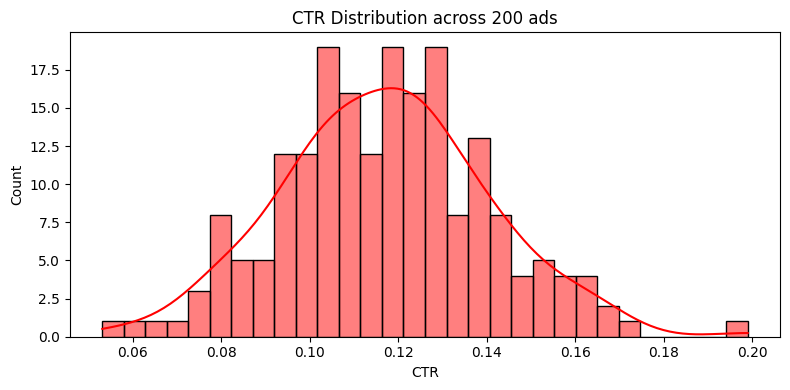

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(ad_full['CTR'], bins = 30, kde = True, color = 'Red')
plt.title('CTR Distribution across 200 ads')
plt.xlabel('CTR')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6327/112273423.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ad_full, x ='ad_platform', y='engagement_score', palette='Set2')


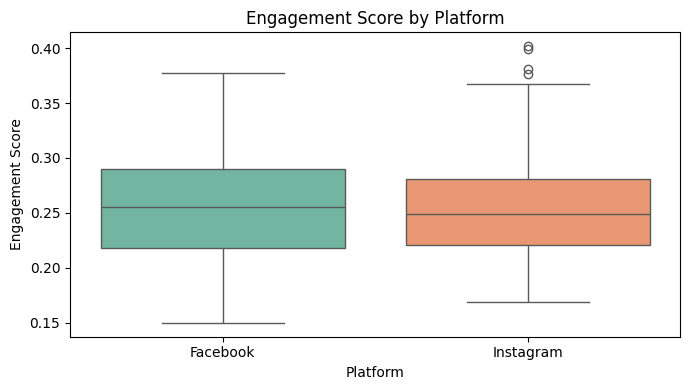

In [15]:
plt.figure(figsize = (7,4))
sns.boxplot(data=ad_full, x ='ad_platform', y='engagement_score', palette='Set2')
plt.title('Engagement Score by Platform')
plt.xlabel('Platform')
plt.ylabel('Engagement Score')
plt.tight_layout()
plt.show()

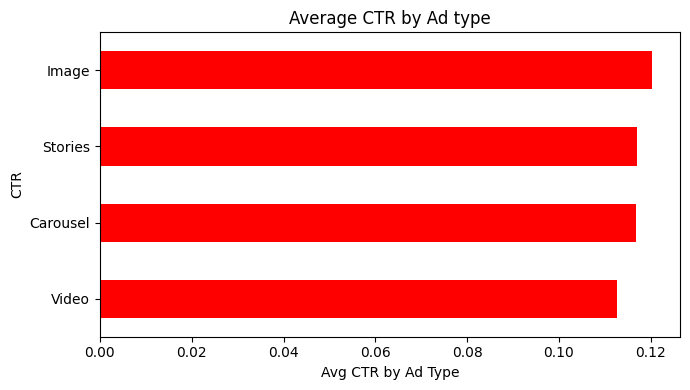

In [16]:
ad_full.groupby('ad_type')['CTR'].mean().sort_values().plot(kind='barh', figsize=(7,4), color = 'red')
plt.title('Average CTR by Ad type')
plt.xlabel('Avg CTR by Ad Type')
plt.ylabel('CTR')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6327/3626637871.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ad_full, x='target_age_group', y='engagement_score', palette='Set3')


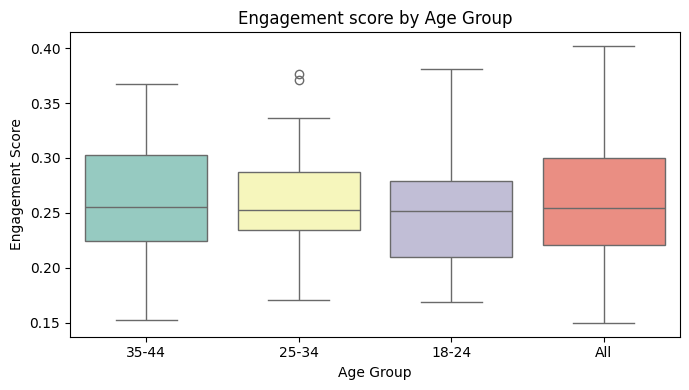

In [17]:
plt.figure(figsize=(7,4))
sns.boxplot(data=ad_full, x='target_age_group', y='engagement_score', palette='Set3')
plt.title('Engagement score by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Engagement Score')
plt.tight_layout()
plt.show()

EDA Summary

1. Dataset is Clean - No NULL values across all 4 files. No cleaning needed. Unusual for real-world data.

2. CTR is normally distributed - centred around 12%, ranging from 6% to 20%. The distribution is slightly right-skewed. Small number of ads outperform the average.

3. Neither platform nor Ad Type separates the performance. Facebook and Instagram have almost Identical engagement scores ( ~0.25 ). Image, Videos, Carousel and Stories all average around 12% CTR. Tabular features alone are weak predictors here - core justification for adding image and text branches.

4. Age group show similar medians but different variance.
35 - 44 has the highest upside but also highest downside.
25 - 34 produced one significant outlier at ~0.38 engagement score.
Targeting wrong age group increases unpredictablity.

5. Engagement Score is chosen over raw CTR.
Formala = ( Clicks*1 + Likes*2 +
Comments*2 + Shares*3 + Purchases*5)/impressions
Purchases are weighted 5 because that represents real revenue.
